<a href="https://colab.research.google.com/github/Snowpuppies2020/Finance/blob/main/%E3%83%AF%E3%83%BC%E3%83%AB%E3%83%89%E3%82%AB%E3%83%83%E3%83%97%E6%9C%9F%E9%96%93%E4%B8%AD%E3%81%AE%E3%82%A4%E3%82%AE%E3%83%AA%E3%82%B9%E3%81%AE%E3%83%91%E3%83%96%E7%89%B9%E9%9C%80%E3%82%92%E8%A6%8B%E8%B6%8A%E3%81%97%E3%81%9F%E3%82%A4%E3%83%99%E3%83%B3%E3%83%88%E3%83%89%E3%83%AA%E3%83%96%E3%83%B3%E3%83%88%E3%83%AC%E3%83%BC%E3%83%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  2 of 2 completed

データをダウンロード中...
--- バックテスト結果 ---
累積リターン: 31.30%
年率リターン: 5.14%
年率リスク(ボラティリティ): 17.48%
シャープレシオ: 0.29


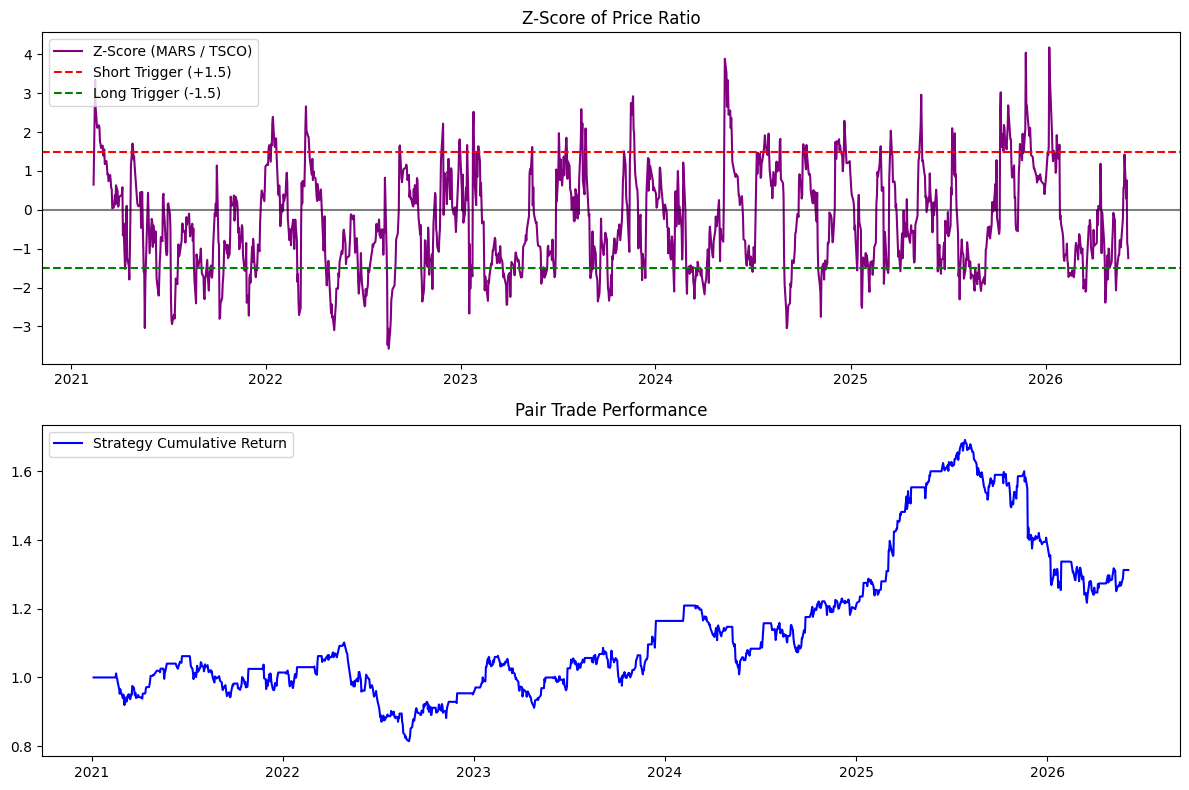

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. データの取得
tickers = ['MARS.L', 'TSCO.L']
# 過去数年分のデータを取得
start_date = '2021-01-01'
end_date = '2026-06-08'

print("データをダウンロード中...")
# auto_adjust=Trueを指定し、Close列を使用するように修正
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)['Close']
data = data.ffill().dropna()

mars = data['MARS.L']
tsco = data['TSCO.L']

# 2. スプレッド（価格比率）の計算
ratio = mars / tsco

# 3. Zスコアの計算とシグナル生成
window = 30 # 移動平均の期間
zscore_threshold = 1.5

rolling_mean = ratio.rolling(window=window).mean()
rolling_std = ratio.rolling(window=window).std()
zscore = (ratio - rolling_mean) / rolling_std

# ポジションの初期化
positions = pd.Series(index=ratio.index, data=0.0)
current_position = 0

for i in range(1, len(zscore)):
    if zscore.iloc[i] < -zscore_threshold and current_position == 0:
        current_position = 1
    elif zscore.iloc[i] > zscore_threshold and current_position == 0:
        current_position = -1
    elif current_position == 1 and zscore.iloc[i] >= 0:
        current_position = 0
    elif current_position == -1 and zscore.iloc[i] <= 0:
        current_position = 0

    positions.iloc[i] = current_position

# 4. リターンの計算
mars_ret = mars.pct_change()
tsco_ret = tsco.pct_change()

portfolio_ret = positions.shift(1) * (mars_ret - tsco_ret) / 2.0
portfolio_ret = portfolio_ret.fillna(0)

# 累積リターン
cumulative_ret = (1 + portfolio_ret).cumprod()

# 5. パフォーマンスの出力と可視化
total_return = cumulative_ret.iloc[-1] - 1
annualized_return = (1 + total_return) ** (252 / len(cumulative_ret)) - 1
annualized_vol = portfolio_ret.std() * np.sqrt(252)
sharpe_ratio = annualized_return / annualized_vol if annualized_vol != 0 else 0

print(f"--- バックテスト結果 ---")
print(f"累積リターン: {total_return:.2%}")
print(f"年率リターン: {annualized_return:.2%}")
print(f"年率リスク(ボラティリティ): {annualized_vol:.2%}")
print(f"シャープレシオ: {sharpe_ratio:.2f}")

# チャート描画
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(zscore, label='Z-Score (MARS / TSCO)', color='purple')
plt.axhline(zscore_threshold, color='red', linestyle='--', label='Short Trigger (+1.5)')
plt.axhline(-zscore_threshold, color='green', linestyle='--', label='Long Trigger (-1.5)')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Z-Score of Price Ratio')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(cumulative_ret, label='Strategy Cumulative Return', color='blue')
plt.title('Pair Trade Performance')
plt.legend()
plt.tight_layout()
plt.show()

['SHEL.L', 'BP.L'] のデータをダウンロード中...


[*********************100%***********************]  2 of 2 completed


--- ['SHEL.L', 'BP.L'] バックテスト結果 ---
累積リターン: 0.98%
年率リターン: 0.18%
年率リスク: 6.44%
シャープレシオ: 0.03


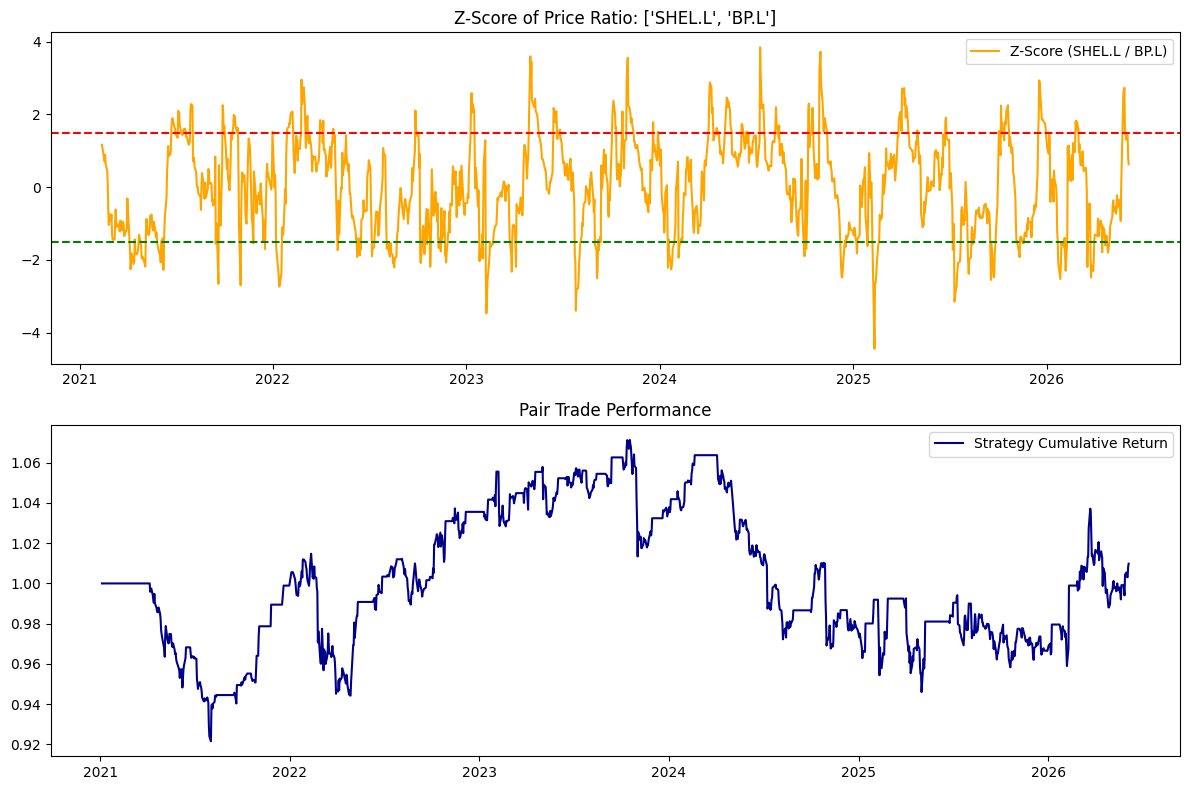

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 銘柄ペアの変更: 石油エネルギーセクター (Shell vs BP) ---
tickers = ['SHEL.L', 'BP.L']
start_date = '2021-01-01'
end_date = '2026-06-08'

print(f"{tickers} のデータをダウンロード中...")
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)['Close']
data = data.ffill().dropna()

stock_a = data[tickers[0]]
stock_b = data[tickers[1]]

# 2. スプレッド（比率）の計算
ratio = stock_a / stock_b

# 3. Zスコアの計算とシグナル生成
window = 30
zscore_threshold = 1.5

rolling_mean = ratio.rolling(window=window).mean()
rolling_std = ratio.rolling(window=window).std()
zscore = (ratio - rolling_mean) / rolling_std

positions = pd.Series(index=ratio.index, data=0.0)
current_position = 0

for i in range(1, len(zscore)):
    if zscore.iloc[i] < -zscore_threshold and current_position == 0:
        current_position = 1
    elif zscore.iloc[i] > zscore_threshold and current_position == 0:
        current_position = -1
    elif current_position == 1 and zscore.iloc[i] >= 0:
        current_position = 0
    elif current_position == -1 and zscore.iloc[i] <= 0:
        current_position = 0
    positions.iloc[i] = current_position

# 4. リターンの計算
ret_a = stock_a.pct_change()
ret_b = stock_b.pct_change()
portfolio_ret = positions.shift(1) * (ret_a - ret_b) / 2.0
portfolio_ret = portfolio_ret.fillna(0)
cumulative_ret = (1 + portfolio_ret).cumprod()

# 5. パフォーマンスの出力
total_return = cumulative_ret.iloc[-1] - 1
annualized_return = (1 + total_return) ** (252 / len(cumulative_ret)) - 1
annualized_vol = portfolio_ret.std() * np.sqrt(252)
sharpe_ratio = annualized_return / annualized_vol if annualized_vol != 0 else 0

print(f"--- {tickers} バックテスト結果 ---")
print(f"累積リターン: {total_return:.2%}")
print(f"年率リターン: {annualized_return:.2%}")
print(f"年率リスク: {annualized_vol:.2%}")
print(f"シャープレシオ: {sharpe_ratio:.2f}")

# チャート描画
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(zscore, label=f'Z-Score ({tickers[0]} / {tickers[1]})', color='orange')
plt.axhline(zscore_threshold, color='red', linestyle='--')
plt.axhline(-zscore_threshold, color='green', linestyle='--')
plt.title(f'Z-Score of Price Ratio: {tickers}')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(cumulative_ret, label='Strategy Cumulative Return', color='darkblue')
plt.title('Pair Trade Performance')
plt.legend()
plt.tight_layout()
plt.show()

['MAB.L', 'MARS.L'] のデータをダウンロード中...


[*********************100%***********************]  2 of 2 completed


--- ['MAB.L', 'MARS.L'] バックテスト結果 ---
累積リターン: 48.45%
年率リターン: 7.55%
年率リスク: 15.42%
シャープレシオ: 0.49


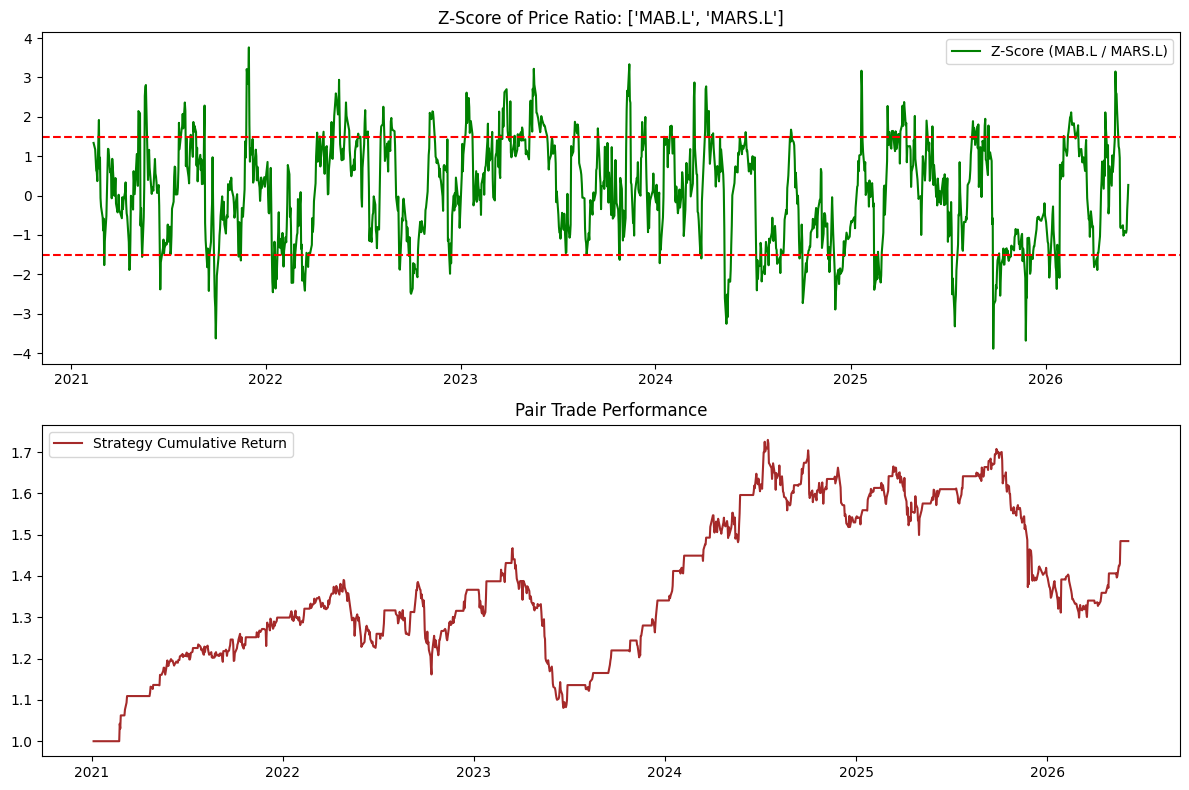

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 銘柄ペアの変更: パブ・レストラン業種 (Mitchells & Butlers vs Marston's) ---
tickers = ['MAB.L', 'MARS.L']
start_date = '2021-01-01'
end_date = '2026-06-08'

print(f"{tickers} のデータをダウンロード中...")
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)['Close']
data = data.ffill().dropna()

stock_a = data[tickers[0]]
stock_b = data[tickers[1]]

# 2. スプレッド（比率）の計算
ratio = stock_a / stock_b

# 3. Zスコアの計算とシグナル生成
window = 30
zscore_threshold = 1.5

rolling_mean = ratio.rolling(window=window).mean()
rolling_std = ratio.rolling(window=window).std()
zscore = (ratio - rolling_mean) / rolling_std

positions = pd.Series(index=ratio.index, data=0.0)
current_position = 0

for i in range(1, len(zscore)):
    if zscore.iloc[i] < -zscore_threshold and current_position == 0:
        current_position = 1
    elif zscore.iloc[i] > zscore_threshold and current_position == 0:
        current_position = -1
    elif current_position == 1 and zscore.iloc[i] >= 0:
        current_position = 0
    elif current_position == -1 and zscore.iloc[i] <= 0:
        current_position = 0
    positions.iloc[i] = current_position

# 4. リターンの計算
ret_a = stock_a.pct_change()
ret_b = stock_b.pct_change()
portfolio_ret = positions.shift(1) * (ret_a - ret_b) / 2.0
portfolio_ret = portfolio_ret.fillna(0)
cumulative_ret = (1 + portfolio_ret).cumprod()

# 5. パフォーマンスの出力
total_return = cumulative_ret.iloc[-1] - 1
annualized_return = (1 + total_return) ** (252 / len(cumulative_ret)) - 1
annualized_vol = portfolio_ret.std() * np.sqrt(252)
sharpe_ratio = annualized_return / annualized_vol if annualized_vol != 0 else 0

print(f"--- {tickers} バックテスト結果 ---")
print(f"累積リターン: {total_return:.2%}")
print(f"年率リターン: {annualized_return:.2%}")
print(f"年率リスク: {annualized_vol:.2%}")
print(f"シャープレシオ: {sharpe_ratio:.2f}")

# チャート描画
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(zscore, label=f'Z-Score ({tickers[0]} / {tickers[1]})', color='green')
plt.axhline(zscore_threshold, color='red', linestyle='--')
plt.axhline(-zscore_threshold, color='red', linestyle='--')
plt.title(f'Z-Score of Price Ratio: {tickers}')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(cumulative_ret, label='Strategy Cumulative Return', color='brown')
plt.title('Pair Trade Performance')
plt.legend()
plt.tight_layout()
plt.show()